# Project Module Test

In this notebook we will be demonstrating how to use our created scripts to recreate the final dataset that will be ready for modeling

### Imports and Installs

In [1]:
import sys
import os

# Allows us to 
sys.path.append(os.path.abspath(os.path.join('..')))

In [2]:
import numpy as np
import pandas as pd
from scripts import cleaning, preprocessing, train_classifier

### Data Import and Cleaning 

In this section we will showing how the use of the cleaning.py script significantly decreases the work load to clean and add features used from the project compared to `notebooks/01_data_wrangling.ipynb`

In [3]:
# Create a simple class to "fake" the command line arguments
class Args:
    i_dir = '../data/raw/'      # Change to the folder where your CSVs are
    o_dir = '../data/interim/'    # Change to where you want the result saved
    shot_file = 'shot.csv'
    rally_file = 'rally.csv'
    game_file = 'game.csv'
    save_file = 'shot_rally_cleaned.csv'

# Create the args object and run the main function
args = Args()
cleaning.main(args)

In [4]:
shot_rally_cleaned_df = pd.read_csv("../data/interim/shot_rally_cleaned.csv")
shot_rally_cleaned_df.head()

,Unnamed: 0,match_id,game_id,rally_id,rally_nbr,rally_len,srv_team_id,rtrn_team_id,w_team_id,shot_id,...,shot_outcome,rally_outcome,delta_x_loc,delta_y_loc,shot_angle,dist_to_kitchen,shot_distance,skill_lvl,srv_point_won,team_hitting
0,0,M99,G178,R7807,65,4,T135,T136,T135,S72059,...,Unforced Error,Game Over,NaN,NaN,NaN,1.08,NaN,5.0,1,0
1,1,M99,G178,R7807,65,4,T135,T136,T135,S72058,...,Winner,Game Over,-0.1330,1.433,1.663343,13.58,13.553878,5.0,1,1
2,2,M99,G178,R7807,65,4,T135,T136,T135,S72057,...,Extend Rally,Game Over,-0.4410,-2.067,-1.780997,13.76,6.242596,5.0,1,0
3,3,M99,G178,R7807,65,4,T135,T136,T135,S72056,...,Start Rally,Game Over,0.5055,2.085,1.332940,13.94,4.953272,5.0,1,1
4,4,M99,G178,R7806,64,4,T135,T136,T135,S72055,...,Unforced Error,Point,NaN,NaN,NaN,0.72,NaN,5.0,1,0


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt


<Axes: >

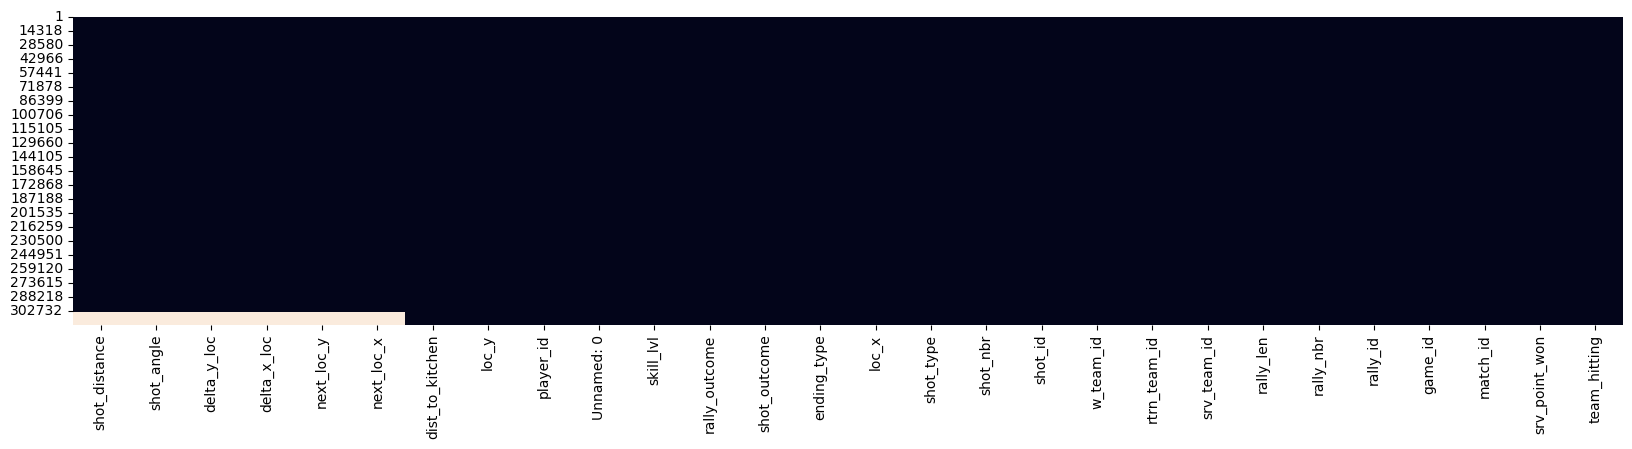

In [6]:
cols=list(shot_rally_cleaned_df.notnull().sum().sort_values().index)
plt.figure(figsize=(20,4))
sns.heatmap(shot_rally_cleaned_df[cols].isnull().sort_values(by=cols), cbar=False)

### Data Preprocessing

In this section we will be applying the preprocessing steps used in `notebooks/03_Preprocessing_Feature_Engineering.ipynb`. 



The results from this preprocessing step will result in the best model parameters and fittinf the test data on the best model.

In [7]:
# Create a simple class to "fake" the command line arguments
class Args:
    i_dir = '../data/interim/'     # Change to the folder where your CSVs are
    o_dir = '../data/testing/'    # Change to where you want the result saved
    shot_file = 'shot_rally_cleaned.csv'
    model_file = 'best_xgb_model.json'
    train_split = 0.8

# Create the args object and run the main function
args = Args()
x_test, y_test, X_unknown, label_encoder = train_classifier.main(args)

Fitting 6 folds for each of 9 candidates, totalling 54 fits


/opt/anaconda3/envs/drexeldsci/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [18:45:29] WARNING: /Users/ec2-user/croot/xgboost-split_1772031718290/work/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/drexeldsci/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [18:45:42] WARNING: /Users/ec2-user/croot/xgboost-split_1772031718290/work/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/drexeldsci/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [18:45:54] WARNING: /Users/ec2-user/croot/xgboost-split_1772031718290/work/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/drexelds

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 600, 'subsample': 0.8}
Best Score: 0.6301


In [8]:
import xgboost as xgb
# Create a new, blank instance of the model class
loaded_model = xgb.XGBClassifier()

# Load the model from the JSON file
loaded_model.load_model("../data/testing/best_xgb_model.json")

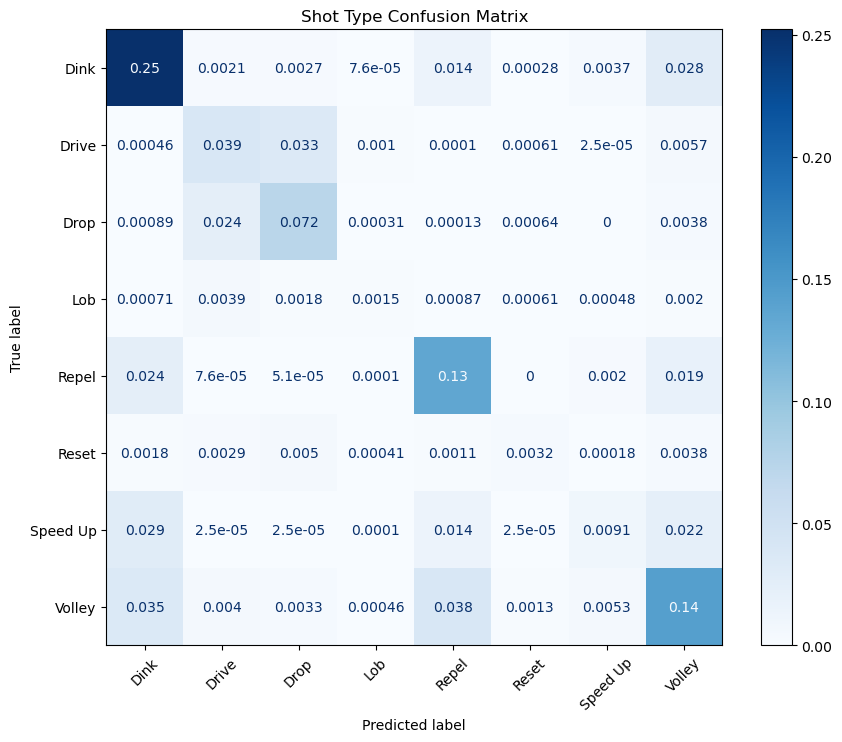

In [9]:
# show confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_predicted = loaded_model.predict(x_test)
cm = confusion_matrix(y_test, y_predicted)

cm = cm/cm.sum().sum()

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=label_encoder.classes_)
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.title('Shot Type Confusion Matrix')
plt.show()

In [10]:
from sklearn.metrics import classification_report
# Drive, Lob, Reset, Speed Up
print(classification_report(y_test, y_predicted, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

        Dink       0.73      0.83      0.78     11921
       Drive       0.51      0.48      0.50      3149
        Drop       0.61      0.71      0.65      4021
         Lob       0.38      0.13      0.19       469
       Repel       0.66      0.75      0.70      7051
       Reset       0.48      0.18      0.26       724
    Speed Up       0.44      0.12      0.19      2914
      Volley       0.63      0.62      0.62      9037

    accuracy                           0.65     39286
   macro avg       0.55      0.48      0.49     39286
weighted avg       0.63      0.65      0.63     39286



In [14]:
from collections import Counter
# Decent spread
y_unknown = loaded_model.predict(X_unknown)
y_unknown = label_encoder.inverse_transform(y_unknown)
Counter(y_unknown)

Counter({'Drop': 9237,
         'Volley': 8500,
         'Drive': 4972,
         'Dink': 4208,
         'Reset': 924,
         'Repel': 913,
         'Lob': 424,
         'Speed Up': 142})